# EDA

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.types import *
from pyspark.sql.functions import *
import boto3
import os
import logging
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.set_option('display.max_columns', None)

In [ ]:
os.environ["SPARK_LOCAL_IP"] = "127.0.0.1"

spark = (SparkSession
    .builder
    .appName("FlightDataETLQuery")
    .config("spark.jars.packages", "org.apache.hadoop:hadoop-aws:3.4.2,com.amazonaws:aws-java-sdk-bundle:1.12.262")
    .config("spark.hadoop.fs.s3a.impl", "org.apache.hadoop.fs.s3a.S3AFileSystem")
    .getOrCreate())

spark.sparkContext.setLogLevel("FATAL")
logging.getLogger("py4j").setLevel(logging.ERROR)
logging.getLogger("pyspark").setLevel(logging.ERROR)

In [ ]:
spark_df = spark.read.parquet("s3a://rwc-ml-datasets/bronze/Flight_Delay_Prediction_Datasets/flight_data/")

In [5]:
spark_df.printSchema()

root
 |-- YEAR: integer (nullable = true)
 |-- QUARTER: integer (nullable = true)
 |-- MONTH: integer (nullable = true)
 |-- DAY_OF_MONTH: integer (nullable = true)
 |-- DAY_OF_WEEK: integer (nullable = true)
 |-- FL_DATE: string (nullable = true)
 |-- OP_UNIQUE_CARRIER: string (nullable = true)
 |-- OP_CARRIER_AIRLINE_ID: integer (nullable = true)
 |-- OP_CARRIER: string (nullable = true)
 |-- TAIL_NUM: string (nullable = true)
 |-- ORIGIN_AIRPORT_ID: integer (nullable = true)
 |-- ORIGIN_AIRPORT_SEQ_ID: integer (nullable = true)
 |-- ORIGIN_CITY_MARKET_ID: integer (nullable = true)
 |-- ORIGIN: string (nullable = true)
 |-- ORIGIN_CITY_NAME: string (nullable = true)
 |-- ORIGIN_STATE_ABR: string (nullable = true)
 |-- ORIGIN_STATE_FIPS: integer (nullable = true)
 |-- ORIGIN_STATE_NM: string (nullable = true)
 |-- ORIGIN_WAC: integer (nullable = true)
 |-- DEST_AIRPORT_ID: integer (nullable = true)
 |-- DEST_AIRPORT_SEQ_ID: integer (nullable = true)
 |-- DEST: string (nullable = true)

In [6]:
print((spark_df.count(), len(spark_df.columns)))

[Stage 1:=======================================>                   (2 + 1) / 3]

(7001619, 60)


In [10]:
spark_df.createOrReplaceTempView("flight_data")

## Statistical summary

In [7]:
spark_df.describe().toPandas()

,summary,YEAR,QUARTER,MONTH,DAY_OF_MONTH,DAY_OF_WEEK,FL_DATE,OP_UNIQUE_CARRIER,OP_CARRIER_AIRLINE_ID,OP_CARRIER,TAIL_NUM,ORIGIN_AIRPORT_ID,ORIGIN_AIRPORT_SEQ_ID,ORIGIN_CITY_MARKET_ID,ORIGIN,ORIGIN_CITY_NAME,ORIGIN_STATE_ABR,ORIGIN_STATE_FIPS,ORIGIN_STATE_NM,ORIGIN_WAC,DEST_AIRPORT_ID,DEST_AIRPORT_SEQ_ID,DEST,DEST_CITY_NAME,DEST_STATE_ABR,DEST_STATE_NM,DEST_WAC,CRS_DEP_TIME,DEP_TIME,DEP_DELAY,DEP_DELAY_NEW,DEP_DEL15,DEP_DELAY_GROUP,DEP_TIME_BLK,TAXI_OUT,WHEELS_OFF,WHEELS_ON,TAXI_IN,CRS_ARR_TIME,ARR_TIME,ARR_DELAY,ARR_DELAY_NEW,ARR_DEL15,ARR_DELAY_GROUP,ARR_TIME_BLK,CANCELLED,CANCELLATION_CODE,DIVERTED,CRS_ELAPSED_TIME,ACTUAL_ELAPSED_TIME,AIR_TIME,FLIGHTS,DISTANCE,DISTANCE_GROUP,CARRIER_DELAY,WEATHER_DELAY,NAS_DELAY,SECURITY_DELAY,LATE_AIRCRAFT_DELAY,FIRST_DEP_TIME,TOTAL_ADD_GTIME
0,count,7001619,7001619,7001619,7001619,7001619,7001619,7001619,7001619,7001619,6989118,7001619,7001619,7001619,7001619,7001619,7001619,7001619,7001619,7001619,7001619,7001619,7001619,7001619,7001619,7001619,7001619,7001619,6903449,6903028,6903028,6903028,6903028,7001619,6899436,6899436,6897011,6897011,7001619,6897011,6879484,6879484,6879484,6879484,7001619,7001619,102876,7001619,7001617,6879484,6879484,7001619,7001619,7001619,1534638,1534638,1534638,1534638,1534638,54513,54498
1,mean,2025.0,2.5238985440367436,6.571155899799746,15.752827453193326,3.999110062972578,NaN,NaN,19947.028030659767,NaN,NaN,12674.984068827509,1267502.6209486693,31733.556382173894,NaN,NaN,NaN,26.839324733322393,NaN,55.33612026018554,12674.838522061826,1267488.0663712206,NaN,NaN,NaN,NaN,55.33503708213772,1323.9459002267904,1328.1103248535624,13.55640669572831,17.045529005532064,0.21756032280326837,0.23343567489513298,NaN,18.64623238769082,1351.5395651180763,1456.3819935911367,8.611399053880007,1492.304588695843,1459.9246519978003,8.504504407598011,17.266110946693097,0.2230745794306666,-0.01891479070232593,NaN,0.01469317310753413,NaN,0.0027505067042351205,148.9098054063797,144.08510042322942,116.84434065113022,1.0,844.4473882397771,3.85023863766366,23.667129968109744,4.632176448126529,15.95794317617575,0.09956875823484106,28.581965909875816,1358.2808137508484,45.685878380858014
2,stddev,0.0,1.1053655450121058,3.394144173864857,8.777954563973077,2.010575071678872,NaN,NaN,367.8615448866353,NaN,NaN,1536.1840251351675,153618.19101180928,1326.8486204999135,NaN,NaN,NaN,16.824857675948618,NaN,26.551914384999666,1536.1823815808723,153618.02661898316,NaN,NaN,NaN,NaN,26.551521722207283,492.21964345818753,510.98174475799,57.5380356568254,56.35457691907855,0.41258678287710787,2.471847535788706,NaN,10.690151758679907,513.7019014639849,543.2835994993334,7.352404748693686,518.5739720584478,548.8612877286957,59.73557564368555,56.28531170940521,0.41630798291065124,2.6437402545920685,NaN,0.12032159340397373,NaN,0.05237310195953011,72.95441364646284,73.25642635293522,71.25512780390814,0.0,601.9752060669796,2.3591610258748044,74.73646020023791,34.81616637943096,36.436840683954706,3.3362523685284744,61.768016077850746,508.35598023055917,40.93303954607312
3,min,2025,1,1,1,1,1/1/2025 12:00:00 AM,AA,19393,AA,188NV,10135,1013506,30070,ABE,"Aberdeen, SD",AK,1,Alabama,1,10135,1013506,ABE,"Aberdeen, SD",AK,Alabama,1,1,1,-115.0,0.0,0.0,-2,0001-0559,1.0,1,1,1.0,1,1,-128.0,0.0,0.0,-2,0001-0559,0.0,A,0.0,-99.0,15.0,7.0,1.0,31.0,1,0.0,0.0,0.0,0.0,0.0,1,1.0
4,max,2025,4,12,31,7,9/9/2025 12:00:00 AM,YX,20452,YX,NTCR2,16869,1686902,36422,YUM,"Yuma, AZ",WY,78,Wyoming,93,16869,1686902,YUM,"Yuma, AZ",WY,Wyoming,93,2400,2400,4352.0,4352.0,1.0,12,2300-2359,1274.0,2400,2400,1318.0,2400,2400,4336.0,4336.0,1.0,12,2300-2359,1.0,D,1.0,1510.0,965.0,953.0,1.0,5095.0,11,4336.0,2394.0,1706.0,990.0,2425.0,2400,506.0


## Missing values

In [8]:
from pyspark.sql import functions as F

In [9]:
spark_df.select([
    F.count(F.when(F.col(c).isNull(), c)).alias(c) for c in spark_df.columns
]).toPandas()

,YEAR,QUARTER,MONTH,DAY_OF_MONTH,DAY_OF_WEEK,FL_DATE,OP_UNIQUE_CARRIER,OP_CARRIER_AIRLINE_ID,OP_CARRIER,TAIL_NUM,ORIGIN_AIRPORT_ID,ORIGIN_AIRPORT_SEQ_ID,ORIGIN_CITY_MARKET_ID,ORIGIN,ORIGIN_CITY_NAME,ORIGIN_STATE_ABR,ORIGIN_STATE_FIPS,ORIGIN_STATE_NM,ORIGIN_WAC,DEST_AIRPORT_ID,DEST_AIRPORT_SEQ_ID,DEST,DEST_CITY_NAME,DEST_STATE_ABR,DEST_STATE_NM,DEST_WAC,CRS_DEP_TIME,DEP_TIME,DEP_DELAY,DEP_DELAY_NEW,DEP_DEL15,DEP_DELAY_GROUP,DEP_TIME_BLK,TAXI_OUT,WHEELS_OFF,WHEELS_ON,TAXI_IN,CRS_ARR_TIME,ARR_TIME,ARR_DELAY,ARR_DELAY_NEW,ARR_DEL15,ARR_DELAY_GROUP,ARR_TIME_BLK,CANCELLED,CANCELLATION_CODE,DIVERTED,CRS_ELAPSED_TIME,ACTUAL_ELAPSED_TIME,AIR_TIME,FLIGHTS,DISTANCE,DISTANCE_GROUP,CARRIER_DELAY,WEATHER_DELAY,NAS_DELAY,SECURITY_DELAY,LATE_AIRCRAFT_DELAY,FIRST_DEP_TIME,TOTAL_ADD_GTIME
0,0,0,0,0,0,0,0,0,0,12501,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,98170,98591,98591,98591,98591,0,102183,102183,104608,104608,0,104608,122135,122135,122135,122135,0,0,6898743,0,2,122135,122135,0,0,0,5466981,5466981,5466981,5466981,5466981,6947106,6947121


## Duplicates

In [41]:
duplicate_rows = (
    spark_df.groupBy(spark_df.columns)
      .count()
      .filter(col("count") > 1)
      .drop("count")
)

In [43]:
duplicate_rows.toPandas()

,YEAR,QUARTER,MONTH,DAY_OF_MONTH,DAY_OF_WEEK,FL_DATE,OP_UNIQUE_CARRIER,OP_CARRIER_AIRLINE_ID,OP_CARRIER,TAIL_NUM,ORIGIN_AIRPORT_ID,ORIGIN_AIRPORT_SEQ_ID,ORIGIN_CITY_MARKET_ID,ORIGIN,ORIGIN_CITY_NAME,ORIGIN_STATE_ABR,ORIGIN_STATE_FIPS,ORIGIN_STATE_NM,ORIGIN_WAC,DEST_AIRPORT_ID,DEST_AIRPORT_SEQ_ID,DEST,DEST_CITY_NAME,DEST_STATE_ABR,DEST_STATE_NM,DEST_WAC,CRS_DEP_TIME,DEP_TIME,DEP_DELAY,DEP_DELAY_NEW,DEP_DEL15,DEP_DELAY_GROUP,DEP_TIME_BLK,TAXI_OUT,WHEELS_OFF,WHEELS_ON,TAXI_IN,CRS_ARR_TIME,ARR_TIME,ARR_DELAY,ARR_DELAY_NEW,ARR_DEL15,ARR_DELAY_GROUP,ARR_TIME_BLK,CANCELLED,CANCELLATION_CODE,DIVERTED,CRS_ELAPSED_TIME,ACTUAL_ELAPSED_TIME,AIR_TIME,FLIGHTS,DISTANCE,DISTANCE_GROUP,CARRIER_DELAY,WEATHER_DELAY,NAS_DELAY,SECURITY_DELAY,LATE_AIRCRAFT_DELAY,FIRST_DEP_TIME,TOTAL_ADD_GTIME


## Class balance

### 15+ delay

In [30]:
arr15_counts_df = spark.sql("select arr_del15, COUNT(arr_del15) as count_per_category from flight_data group by arr_del15").toPandas()
arr15_counts_df.head()

,arr_del15,count_per_category
0,0.0,5344846
1,NaN,0
2,1.0,1534638


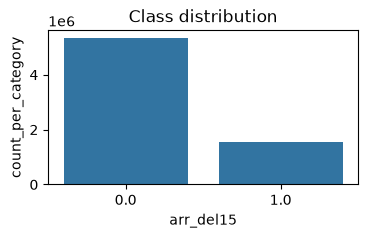

In [29]:
plt.figure(figsize=(4, 2))
sns.barplot(data=arr15_counts_df, x='arr_del15', y='count_per_category')
plt.title("Class distribution")
plt.show()

### Arrival delay group

In [31]:
arr_delay_grp_df = spark.sql("select arr_delay_group, COUNT(arr_delay_group) as count_per_group from flight_data group by arr_delay_group").toPandas()
arr_delay_grp_df.head()

,arr_delay_group,count_per_group
0,-1.0,2466522
1,12.0,111405
2,NaN,0
3,1.0,512828
4,6.0,67207


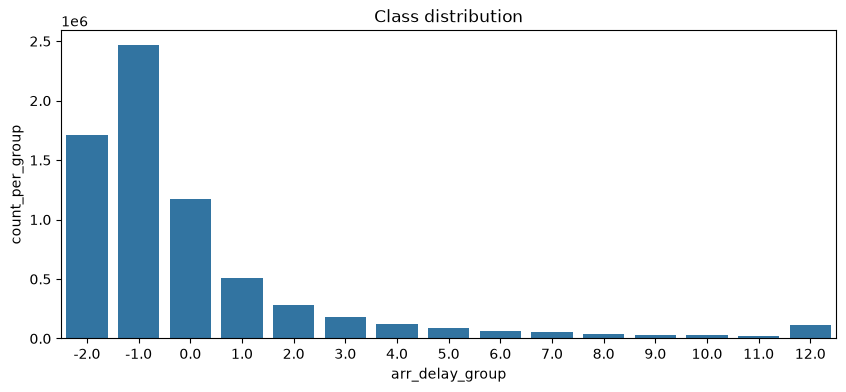

In [38]:
plt.figure(figsize=(10, 4))
sns.barplot(data=arr_delay_grp_df, x='arr_delay_group', y='count_per_group')
plt.title("Class distribution")
plt.show()